In [12]:
# Predict price from the automobile data using Linear Regression

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
data = pd.read_csv('Automobile_data.csv')

In [14]:
#find all occurences of '? in the dataframe and replace with np.nan
data.replace('?', np.nan, inplace=True)
data.drop(columns=['normalized-losses'], inplace=True)


In [15]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   make               205 non-null    object 
 2   fuel-type          205 non-null    object 
 3   aspiration         205 non-null    object 
 4   num-of-doors       203 non-null    object 
 5   body-style         205 non-null    object 
 6   drive-wheels       205 non-null    object 
 7   engine-location    205 non-null    object 
 8   wheel-base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb-weight        205 non-null    int64  
 13  engine-type        205 non-null    object 
 14  num-of-cylinders   205 non-null    object 
 15  engine-size        205 non-null    int64  
 16  fuel-system        205 non

In [16]:
# some of the columns are identified as objects but hold numerical data, either float or int
data['bore'] = data['bore'].astype(float)
data['stroke'] = data['stroke'].astype(float)
data['horsepower'] = pd.to_numeric(data['horsepower'], errors = 'coerce')
data['peak-rpm'] = data['peak-rpm'].astype(float)
data['price'] = pd.to_numeric(data['price'], errors = 'raise')
#replace text values in num of doors and number of cylinders with numerical values and convert them to int
data['num-of-doors'].replace({'four':4, 'two':2}, inplace = True)
data['num-of-cylinders'].replace({'four':4, 'six':6, 'five':5, 'three':3, 'twelve':12, 'eight': 8, 'two': 2}, inplace = True)
data['num-of-doors'] = pd.to_numeric(data['num-of-doors'], errors = 'raise')
data['num-of-cylinders'] = pd.to_numeric(data['num-of-cylinders'], errors = 'raise')
#replace text values in fuel-type, aspiration, drive-wheel, engine position with numerical values and convert them to int
data.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   make               205 non-null    object 
 2   fuel-type          205 non-null    object 
 3   aspiration         205 non-null    object 
 4   num-of-doors       203 non-null    float64
 5   body-style         205 non-null    object 
 6   drive-wheels       205 non-null    object 
 7   engine-location    205 non-null    object 
 8   wheel-base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb-weight        205 non-null    int64  
 13  engine-type        205 non-null    object 
 14  num-of-cylinders   205 non-null    int64  
 15  engine-size        205 non-null    int64  
 16  fuel-system        205 non

In [17]:
# impute missing door values group by body-style and take the mode
# impte missing  bore and stoke values groupby compression-ratio and take mean value
# impute missing price group by make and take max value
# impute horsepower , peak rpm group by highway mpg and take mean value
data['num-of-doors'].fillna(data.groupby('body-style')['num-of-doors'].transform('mean'), inplace=True)
data['bore'].fillna(data.groupby('compression-ratio')['bore'].transform('mean'), inplace=True)
data['stroke'].fillna(data.groupby('compression-ratio')['stroke'].transform('mean'), inplace=True)
data['price'].fillna(data.groupby('make')['price'].transform('max'), inplace=True)
data['horsepower'].fillna(data.groupby('highway-mpg')['horsepower'].transform('mean'), inplace=True)
data['peak-rpm'].fillna(data.groupby('highway-mpg')['peak-rpm'].transform('mean'), inplace=True)


In [18]:
#categorical_columns = data.select_dtypes(include =['object']).columns.tolist()
categorical_columns = data.select_dtypes(exclude = np.number).columns.tolist()
#numerical_columns = data.select_dtypes(include = ['int64', 'float64']).columns.tolist()
numerical_columns = data.select_dtypes(include = np.number).columns.tolist()

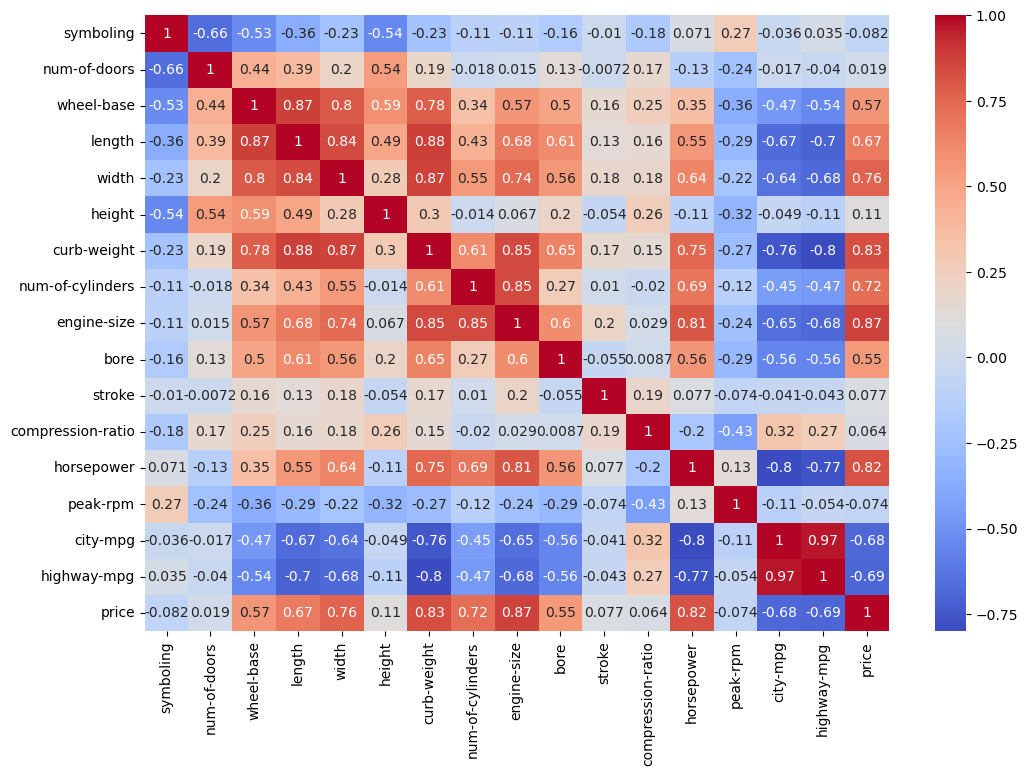

In [19]:
#heatmap of correlation between numerical columns
plt.figure(figsize=(12,8))
sns.heatmap(data[numerical_columns].corr(), annot = True, cmap = 'coolwarm')
plt.show()

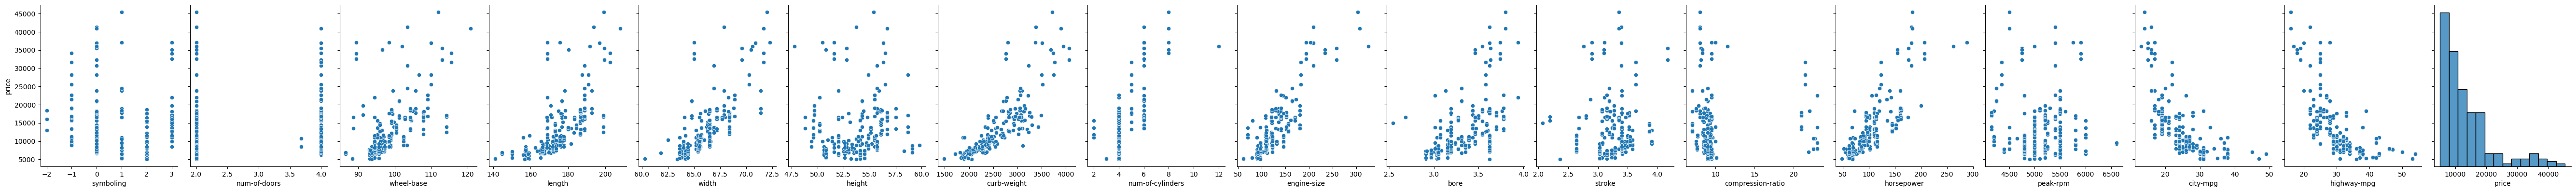

In [20]:
sns.pairplot(data = data, x_vars = numerical_columns, y_vars ='price', height = 4, aspect = 0.8, kind = 'scatter')

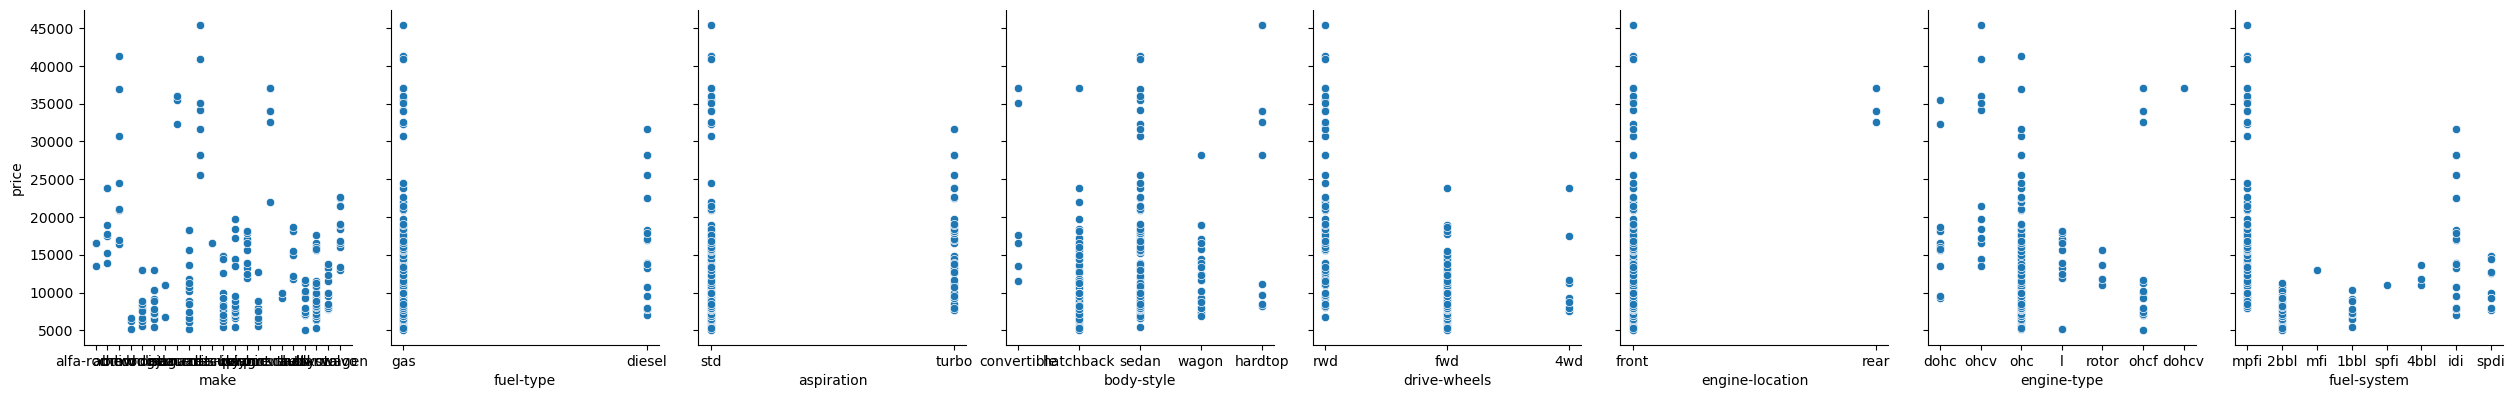

In [21]:
sns.pairplot(data=data, x_vars = categorical_columns, y_vars = 'price', height = 4, aspect = 0.8, kind = 'scatter')

In [22]:
# lets drop few columns that doesn't add much value to our analysis
data.drop(columns=['symboling', 'peak-rpm', 'city-mpg', 'highway-mpg'], inplace=True)


    


In [23]:
#build pipeline for preprocessing and modeling
#split data into X and y
y = data['price']
X = data.drop(columns=['price'])
num_features = X.select_dtypes(include = np.number).columns.tolist()
cat_features = X.select_dtypes(exclude = np.number).columns.tolist()
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size =0.4, random_state=42)
#preprocessing for numerical data
num_transformer = StandardScaler()
#preprocessing for categorical data
cat_transformer = OneHotEncoder(handle_unknown='ignore')
#bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)
#define the model
model=LinearRegression()
#create and end to end pipeline
linear_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', model)
])
#fit the model
linear_pipeline.fit(train_X, train_y)
#make predictions
preds = linear_pipeline.predict(test_X)
#evaluate the model
mae = mean_absolute_error(test_y, preds)
mse = mean_squared_error(test_y, preds)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, preds)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')






MAE: 1825.8020868635624
MSE: 6857909.379003281
RMSE: 2618.761038927241
R2 Score: 0.8854479824834538
